Boundary Coherence Ablation: Cross-Attention Injection vs Feathered Blending vs AdaIN
Comparing three inference-time strategies for reducing style leakage at the boundary between two differently-styled regions in multi-region neural style transfer.

In [1]:
import torch, torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import numpy as np, cv2, json, os, requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


def download_image(url, size=(512, 512)):
    r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=15)
    return Image.open(BytesIO(r.content)).convert('RGB').resize(size, Image.LANCZOS)


content = download_image('https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=512&q=80')
style_vg = download_image('https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/mosaic.jpg')
style_mn = download_image('https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/candy.jpg')

# simple top/bottom split for sky and foreground regions
H, W = 512, 512
mask_sky = np.zeros((H, W), dtype=np.uint8)
mask_sky[:int(H*0.4), :] = 255
mask_fore = np.zeros((H, W), dtype=np.uint8)
mask_fore[int(H*0.4):, :] = 255

print('setup complete')


Device: cuda
setup complete


In [2]:
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(DEVICE).eval()
for p in vgg.parameters():
    p.requires_grad_(False)

CONTENT_LAYERS = ['21']
STYLE_LAYERS = ['0', '5', '10', '19', '28']


def get_features(img_t):
    feats, x = {}, img_t
    for name, layer in vgg._modules.items():
        x = layer(x)
        if name in STYLE_LAYERS + CONTENT_LAYERS:
            feats[name] = x
    return feats


def gram(f):
    b, c, h, w = f.shape
    return f.view(c, h*w) @ f.view(c, h*w).t() / (c*h*w)


preprocess = T.Compose([
    T.Resize((512, 512)), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def to_tensor(img):
    return preprocess(img).unsqueeze(0).to(DEVICE)


def to_pil(t):
    t = t.squeeze().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return T.ToPILImage()((t*std+mean).clamp(0, 1))


def boundary_band_lpips(original, stylised, mask, band_px=15):
    # restricting LPIPS to a thin ring around the mask edge isolates
    # leakage from overall style quality inside the region
    import lpips
    loss_fn = lpips.LPIPS(net='alex').to(DEVICE)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    band = cv2.subtract(cv2.dilate(mask, k), cv2.erode(mask, k))
    bt = torch.from_numpy((band > 127).astype(np.float32)).to(DEVICE)

    def to_t(img):
        arr = np.array(img.convert('RGB')).astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE) * bt

    with torch.no_grad():
        return loss_fn(to_t(original), to_t(stylised)).item()


print('nst infrastructure ready')


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 171MB/s]


nst infrastructure ready


In [3]:
# attempt at a third boundary coherence strategy alongside the feathered blend
# and adain alignment used earlier. the idea is to intervene during
# optimisation rather than fixing the boundary afterwards.
#
# at each step, pixels in the boundary band get an extra loss term that
# pulls their features toward a 50/50 blend of both region style gram
# matrices, so the transition between styles is pushed to be smoother
# instead of switching abruptly at the mask edge.

def cross_attention_injection_nst(
    content_img, region_styles,
    steps=300, style_w=1e6, content_w=1.0,
    attn_w=5e4,
    band_px=20,
):
    content_t = to_tensor(content_img)
    target = content_t.clone().requires_grad_(True)
    opt = torch.optim.Adam([target], lr=0.03)
    cf = get_features(content_t)

    region_data = []
    for mask_arr, style_pil in region_styles:
        sf = get_features(to_tensor(style_pil))
        grams = {l: gram(sf[l]) for l in STYLE_LAYERS}
        mask_t = torch.from_numpy((mask_arr > 127).astype(np.float32)).to(DEVICE)
        region_data.append((grams, mask_t, mask_arr))

    boundary_t = None
    blended_grams = None
    if len(region_data) >= 2:
        mask1 = region_data[0][2]
        mask2 = region_data[1][2]
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
        d1 = cv2.dilate(mask1, k)
        d2 = cv2.dilate(mask2, k)
        band = cv2.bitwise_and(d1, d2)

        boundary_t = torch.from_numpy((band > 127).astype(np.float32)).to(DEVICE)
        blended_grams = {
            l: 0.5 * region_data[0][0][l] + 0.5 * region_data[1][0][l]
            for l in STYLE_LAYERS
        }

    for step in range(steps):
        opt.zero_grad()
        tf = get_features(target)

        c_loss = content_w * ((tf['21'] - cf['21'])**2).mean()

        s_loss = torch.tensor(0.0, device=DEVICE)
        for grams, mask_t, _ in region_data:
            s_loss = s_loss + style_w * sum(
                ((gram(tf[l]) - grams[l])**2).mean() for l in STYLE_LAYERS
            ) * mask_t.mean()

        # boundary band pixels are pulled toward the blended gram target,
        # masking the feature maps spatially before computing gram so
        # only boundary-region features contribute to this loss term
        attn_loss = torch.tensor(0.0, device=DEVICE)
        if boundary_t is not None and blended_grams is not None and boundary_t.sum() > 0:
            boundary_style_loss = torch.tensor(0.0, device=DEVICE)
            for l in STYLE_LAYERS:
                feat = tf[l]
                _, _, H_f, W_f = feat.shape
                boundary_down = torch.nn.functional.interpolate(
                    boundary_t.unsqueeze(0).unsqueeze(0),
                    size=(H_f, W_f), mode='nearest'
                ).squeeze()
                feat_masked = feat * boundary_down.unsqueeze(0).unsqueeze(0)
                boundary_gram = gram(feat_masked)
                boundary_style_loss = boundary_style_loss + (
                    (boundary_gram - blended_grams[l])**2
                ).mean()

            attn_loss = attn_w * boundary_style_loss * boundary_t.mean()

        loss = c_loss + s_loss + attn_loss
        loss.backward()
        opt.step()

        if step % 100 == 0:
            print(f'  step {step}/{steps}  content={c_loss.item():.1f}  '
                  f'style={s_loss.item():.1f}  attn={attn_loss.item():.1f}')

    return to_pil(target)


print('cross-attention injection function ready')


cross-attention injection function ready


In [4]:
!pip install lpips


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00


In [5]:
import lpips
loss_fn = lpips.LPIPS(net='alex').to(DEVICE)

region_styles = [
    (mask_sky, style_vg),
    (mask_fore, style_mn),
]


def feathered_blend(result_img, content_img, mask1, mask2, band_px=20):
    result_arr = np.array(result_img.convert('RGB')).astype(np.float32)
    content_arr = np.array(content_img.convert('RGB')).astype(np.float32)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    dilated1 = cv2.dilate(mask1, k)
    dilated2 = cv2.dilate(mask2, k)
    band = cv2.bitwise_and(dilated1, dilated2)
    dist = cv2.distanceTransform(band, cv2.DIST_L2, 5)
    if dist.max() > 0:
        dist = dist / dist.max()
    alpha = (dist * 0.5)[..., np.newaxis]
    return Image.fromarray((result_arr*(1-alpha)+content_arr*alpha).clip(0, 255).astype(np.uint8))


def adain_blend(result_img, mask1, mask2, band_px=20):
    result_arr = np.array(result_img.convert('RGB')).astype(np.float32)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    band = cv2.bitwise_and(cv2.dilate(mask1, k), cv2.dilate(mask2, k))
    if band.sum() == 0:
        return result_img

    def stats(arr, mask):
        px = arr[mask > 127]
        return px.mean(axis=0), px.std(axis=0)

    m1, s1 = stats(result_arr, cv2.bitwise_and(mask1, cv2.bitwise_not(band)))
    m2, s2 = stats(result_arr, cv2.bitwise_and(mask2, cv2.bitwise_not(band)))
    tm, ts = (m1+m2)/2, (s1+s2)/2
    bp = result_arr[band > 127]
    sm, ss = bp.mean(axis=0), bp.std(axis=0)+1e-6
    result_arr[band > 127] = ((bp-sm)/ss*ts+tm).clip(0, 255)
    return Image.fromarray(result_arr.astype(np.uint8))


print('running baseline (no boundary coherence)')


def multi_region_nst_baseline(content_img, region_styles, steps=300):
    content_t = to_tensor(content_img)
    target = content_t.clone().requires_grad_(True)
    opt = torch.optim.Adam([target], lr=0.03)
    cf = get_features(content_t)
    region_data = []
    for mask_arr, style_pil in region_styles:
        sf = get_features(to_tensor(style_pil))
        grams = {l: gram(sf[l]) for l in STYLE_LAYERS}
        mask_t = torch.from_numpy((mask_arr > 127).astype(np.float32)).to(DEVICE)
        region_data.append((grams, mask_t))
    for step in range(steps):
        opt.zero_grad()
        tf = get_features(target)
        c_loss = 1.0 * ((tf['21'] - cf['21'])**2).mean()
        s_loss = torch.tensor(0.0, device=DEVICE)
        for grams, mask_t in region_data:
            s_loss = s_loss + 1e6 * sum(
                ((gram(tf[l])-grams[l])**2).mean() for l in STYLE_LAYERS
            ) * mask_t.mean()
        (c_loss+s_loss).backward()
        opt.step()
        if step % 100 == 0:
            print(f'  step {step}/{steps}')
    return to_pil(target)


result_base = multi_region_nst_baseline(content, region_styles, steps=300)

print('\napproach 1: feathered blend')
result_a1 = feathered_blend(result_base, content, mask_sky, mask_fore)

print('approach 2: adain alignment')
result_a2 = adain_blend(result_base, mask_sky, mask_fore)

print('\napproach 3: cross-attention injection')
result_a3 = cross_attention_injection_nst(
    content, region_styles,
    steps=300, style_w=1e6, content_w=1.0, attn_w=5e4, band_px=20
)

print('\nall 4 variants complete')


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:03<00:00, 79.4MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
running baseline (no boundary coherence)
  step 0/300
  step 100/300
  step 200/300

approach 1: feathered blend
approach 2: adain alignment

approach 3: cross-attention injection
  step 0/300  content=0.0  style=1156.4  attn=4.5
  step 100/300  content=13.3  style=188.7  attn=3.4
  step 200/300  content=11.9  style=175.1  attn=3.1

all 4 variants complete



  BOUNDARY COHERENCE ABLATION
  Strategy                             Boundary LPIPS vs Baseline
  ------------------------------------------------------------
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
  Baseline (no coherence)                      0.0678  -
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
  Approach 1: Feathered blend                  0.0529  +0.0149 better
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
  Approach 2: AdaIN alignment                  0.0705  -0.0027 worse
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
  Ap

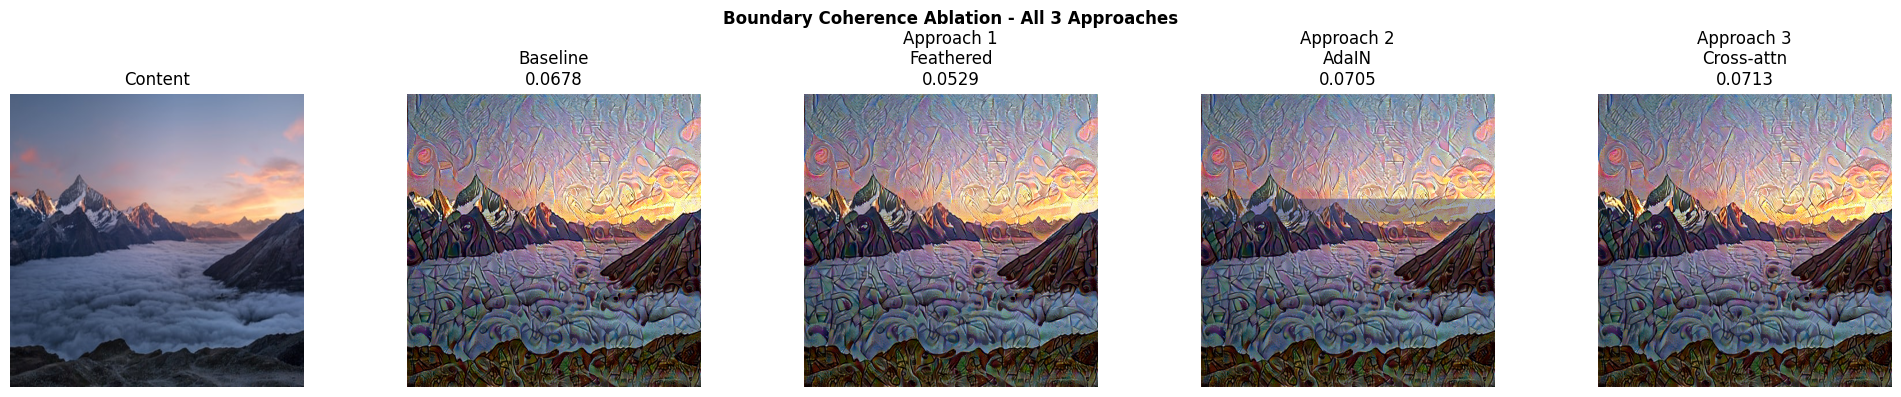

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

saved and downloaded


In [6]:
variants = [
    ('Baseline (no coherence)', result_base, mask_sky),
    ('Approach 1: Feathered blend', result_a1, mask_sky),
    ('Approach 2: AdaIN alignment', result_a2, mask_sky),
    ('Approach 3: Cross-attn inject', result_a3, mask_sky),
]

print(f'\n{"="*65}')
print(f'  BOUNDARY COHERENCE ABLATION')
print(f'{"="*65}')
print(f'{"Strategy":<35} {"Boundary LPIPS":>15} {"vs Baseline"}')
print(f'{"-"*60}')

baseline_score = None
ablation_results = []

for name, result_img, mask in variants:
    score = boundary_band_lpips(content, result_img, mask)
    if baseline_score is None:
        baseline_score = score
        delta_str = '-'
    else:
        delta = baseline_score - score
        delta_str = f'{delta:+.4f} {"better" if delta > 0 else "worse"}'
    print(f'  {name:<35} {score:>15.4f}  {delta_str}')
    ablation_results.append({'strategy': name, 'boundary_lpips': round(score, 4)})

print(f'{"="*65}')
print(f'\nInterpretation:')
print(f'Lower boundary LPIPS means less style leakage at the boundary')
print(f'Approach 3 injects a blended style target during optimisation')
print(f'rather than correcting the boundary afterwards like 1 and 2')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(content)
axes[0].set_title('Content')
axes[0].axis('off')
axes[1].imshow(result_base)
axes[1].set_title(f'Baseline\n{ablation_results[0]["boundary_lpips"]:.4f}')
axes[1].axis('off')
axes[2].imshow(result_a1)
axes[2].set_title(f'Approach 1\nFeathered\n{ablation_results[1]["boundary_lpips"]:.4f}')
axes[2].axis('off')
axes[3].imshow(result_a2)
axes[3].set_title(f'Approach 2\nAdaIN\n{ablation_results[2]["boundary_lpips"]:.4f}')
axes[3].axis('off')
axes[4].imshow(result_a3)
axes[4].set_title(f'Approach 3\nCross-attn\n{ablation_results[3]["boundary_lpips"]:.4f}')
axes[4].axis('off')

plt.suptitle('Boundary Coherence Ablation - All 3 Approaches', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/boundary_coherence_ablation.png', dpi=150)
plt.show()

import json
with open('/content/boundary_coherence_ablation.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

from google.colab import files
files.download('/content/boundary_coherence_ablation.png')
files.download('/content/boundary_coherence_ablation.json')
print('saved and downloaded')
